# **Project Name - Aerial Object Classification & Detection**


#### Import Libraries

In [15]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.models as models

from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report

#### Understand the Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Copy everything from Drive to Colab's high-speed local storage
!cp -r /content/drive/MyDrive/dataset /content


Mounted at /content/drive


Execution Backend: cuda
[Train Set] Birds: 1414 | Drones: 1267 | Total: 2681
[Valid Set] Birds: 217 | Drones: 225 | Total: 442
[Test Set] Birds: 121 | Drones: 94 | Total: 215


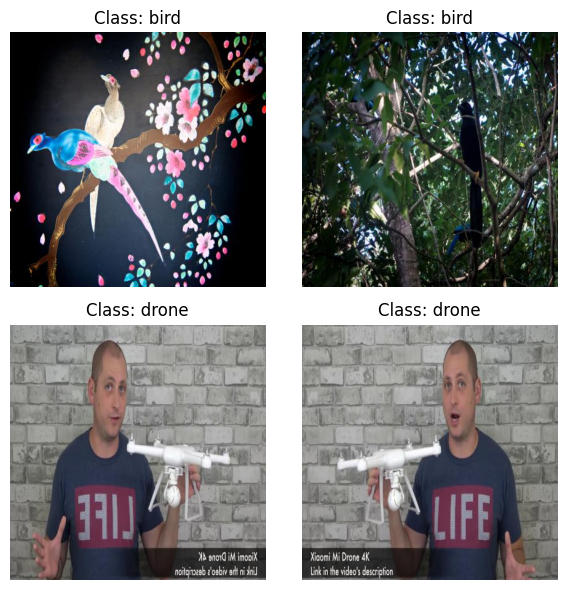

In [45]:
import os
import copy
import time
import glob
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# Configure global execution settings
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Execution Backend: {device}")

# Path definitions
train_path = "/content/dataset/train"
valid_path = "/content/dataset/valid"
test_path = "/content/dataset/test"

splits = [("Train", train_path), ("Valid", valid_path), ("Test", test_path)]
performance_summary = {}

for split_name, split_path in splits:
    if os.path.exists(split_path):
        birds = len(glob.glob(os.path.join(split_path, "bird/*")))
        drones = len(glob.glob(os.path.join(split_path, "drone/*")))
        print(f"[{split_name} Set] Birds: {birds} | Drones: {drones} | Total: {birds + drones}")

        # Quantify class imbalance
        imbalance_ratio = max(birds, drones) / (min(birds, drones) + 1e-6)
        if imbalance_ratio > 1.5:
            print(f"  Note: Class imbalance detected in {split_name} (Ratio: {imbalance_ratio:.2f}:1)")
    else:
        print(f"Error: Missing path at {split_path}")

def inspect_and_save_samples(base_path, num_samples=2):
    fig, axes = plt.subplots(2, num_samples, figsize=(6, 6))
    for idx, class_name in enumerate(["bird", "drone"]):
        img_paths = glob.glob(os.path.join(base_path, class_name, "*"))[:num_samples]
        for i, img_path in enumerate(img_paths):
            img = Image.open(img_path)
            axes[idx, i].imshow(img)
            axes[idx, i].set_title(f"Class: {class_name}")
            axes[idx, i].axis('off')
    plt.tight_layout()
    plt.savefig('dataset_samples.png')
    plt.show()
inspect_and_save_samples(train_path)


In [46]:
# ImageNet reference stats required for pre-trained PyTorch backbones
mean_stats = [0.485, 0.456, 0.406]
std_stats = [0.229, 0.224, 0.225]

# Augmentation chain includes zoom (scale parameter), rotation, flipping, brightness changes, and crops
transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean_stats, std_stats),
])

transform_eval = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean_stats, std_stats)
])

train_data = datasets.ImageFolder(root=train_path, transform=transform_train)
valid_data = datasets.ImageFolder(root=valid_path, transform=transform_eval)
test_data = datasets.ImageFolder(root=test_path, transform=transform_eval)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

num_classes = len(train_data.classes)
print(f"Data Loaders Initialized. Target classes: {train_data.classes}")


Data Loaders Initialized. Target classes: ['bird', 'drone']


In [47]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25),

            nn.Conv2d(256, 32, kernel_size=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 14 * 14, 256),
            nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

def construct_resnet50_transfer(num_classes=2):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    # Freeze core weights to prevent over-fitting on sparse inputs
    for param in model.parameters():
        param.requires_grad = False

    # Restructure fully connected head for target categories
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(inplace=True), nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model.to(device)


In [48]:
def execution_training_engine(model, criterion, optimizer, num_epochs=20, patience=5, file_destination='checkpoint.pth'):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    epochs_no_improve = 0

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.1)

    start_time = time.time()

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch}/{num_epochs - 1}')
        print('-' * 15)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = valid_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloader, desc=f'{phase.capitalize()} Processing'):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = (running_corrects.double() / len(dataloader.dataset)).item()

            print(f'{phase.capitalize()} Metrics -> Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                scheduler.step(epoch_loss)

                # EarlyStopping & ModelCheckpoint Mechanism Logic
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(best_model_wts, file_destination)
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

                if epochs_no_improve >= patience:
                    print(f'Early stopping triggered after {patience} epochs without validation loss drop.')
                    elapsed_run_time = time.time() - start_time
                    model.load_state_dict(best_model_wts)
                    return model, history, elapsed_run_time
            else:
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)

    elapsed_run_time = time.time() - start_time
    model.load_state_dict(best_model_wts)
    return model, history, elapsed_run_time


In [49]:
def compute_evaluation_charts(model, history, label_identifier="Model"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(f"\n===== Test Evaluation Analysis: {label_identifier} =====")
    report_dict = classification_report(all_labels, all_preds, target_names=train_data.classes, output_dict=True)
    print(classification_report(all_labels, all_preds, target_names=train_data.classes))

    # Save Loss and Accuracy Learning Curves
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'{label_identifier} Loss Architecture')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title(f'{label_identifier} Accuracy Convergence')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{label_identifier.lower()}_evaluation_curves.png')
    plt.show()

    # Save Confusion Matrix Blueprint Map
    matrix_data = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(matrix_data, annot=True, fmt='d', cmap='Blues',
                xticklabels=train_data.classes, yticklabels=train_data.classes)
    plt.title(f'{label_identifier} Confusion Matrix')
    plt.ylabel('True Group')
    plt.xlabel('Predicted Group')
    plt.tight_layout()
    plt.savefig(f'{label_identifier.lower()}_confusion_matrix.png')
    plt.show()

    return report_dict['accuracy']



==================== TRAINING CUSTOM CNN BLOCK ====================

Epoch 0/24
---------------


Train Processing: 100%|██████████| 84/84 [00:27<00:00,  3.10it/s]


Train Metrics -> Loss: 0.6084 Acc: 0.6587


Val Processing: 100%|██████████| 14/14 [00:02<00:00,  5.87it/s]


Val Metrics -> Loss: 0.6602 Acc: 0.5701

Epoch 1/24
---------------


...

Train Processing: 100%|██████████| 84/84 [00:21<00:00,  3.91it/s]


Train Metrics -> Loss: 0.3016 Acc: 0.8750


Val Processing: 100%|██████████| 14/14 [00:03<00:00,  4.51it/s]

Val Metrics -> Loss: 1.0502 Acc: 0.5633
Early stopping triggered after 6 epochs without validation loss drop.



===== Test Evaluation Analysis: Custom_CNN =====
              precision    recall  f1-score   support

        bird       0.64      0.84      0.73       121
       drone       0.65      0.38      0.48        94

    accuracy                           0.64       215
   macro avg       0.65      0.61      0.60       215
weighted avg       0.64      0.64      0.62       215



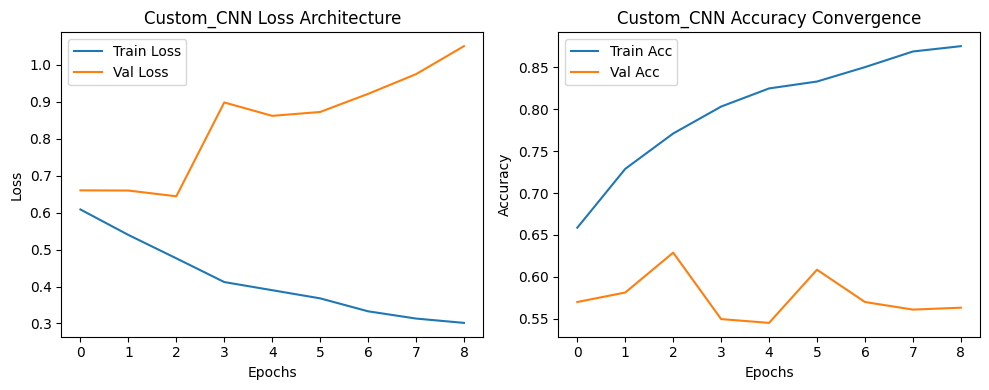

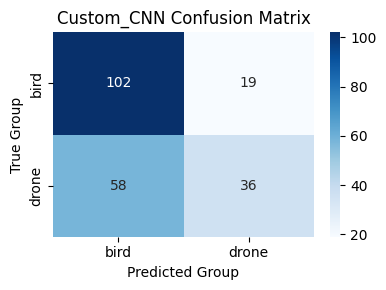


==================== TRAINING RESNET50 TRANSFER BLOCK ====================
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 147MB/s]



Epoch 0/24
---------------


Train Processing: 100%|██████████| 84/84 [00:22<00:00,  3.78it/s]


Train Metrics -> Loss: 0.1364 Acc: 0.9433


...

Train Processing: 100%|██████████| 84/84 [00:24<00:00,  3.38it/s]


Train Metrics -> Loss: 0.0183 Acc: 0.9940


Val Processing: 100%|██████████| 14/14 [00:02<00:00,  6.10it/s]

Val Metrics -> Loss: 0.0351 Acc: 0.9819
Early stopping triggered after 6 epochs without validation loss drop.



===== Test Evaluation Analysis: ResNet50_Transfer =====
              precision    recall  f1-score   support

        bird       0.97      1.00      0.98       121
       drone       1.00      0.96      0.98        94

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



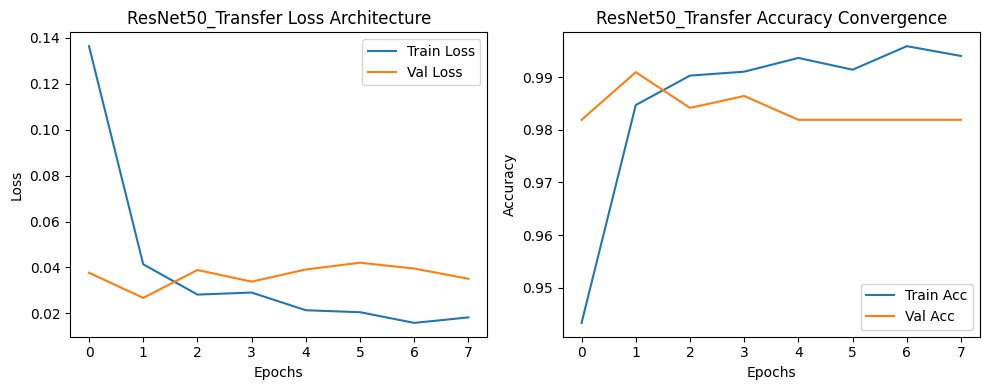

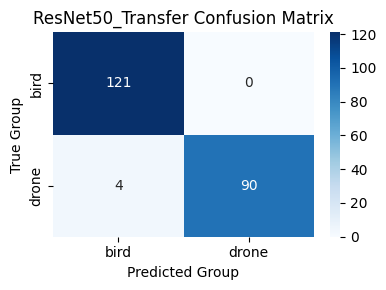

In [50]:
# System configurations
loss_criterion = nn.CrossEntropyLoss()
total_max_epochs = 25
patience_threshold = 6

# Execute Custom CNN Processing
print("\n==================== TRAINING CUSTOM CNN BLOCK ====================")
custom_net = CustomCNN(num_classes=num_classes).to(device)
opt_custom = optim.Adam(custom_net.parameters(), lr=1e-4, weight_decay=1e-4)

custom_net, log_custom, runtime_custom = execution_training_engine(
    custom_net, loss_criterion, opt_custom, num_epochs=total_max_epochs,
    patience=patience_threshold, file_destination='best_custom_cnn.pth'
)
test_accuracy_custom = compute_evaluation_charts(custom_net, log_custom, label_identifier="Custom_CNN")
performance_summary["Custom_CNN"] = {"accuracy": test_accuracy_custom, "time": runtime_custom, "weights": 'best_custom_cnn.pth'}

# Execute Transfer Learning Processing
print("\n==================== TRAINING RESNET50 TRANSFER BLOCK ====================")
resnet_net = construct_resnet50_transfer(num_classes=num_classes)
opt_transfer = optim.Adam(resnet_net.fc.parameters(), lr=1e-3, weight_decay=1e-4)

resnet_net, log_transfer, runtime_transfer = execution_training_engine(
    resnet_net, loss_criterion, opt_transfer, num_epochs=total_max_epochs,
    patience=patience_threshold, file_destination='best_resnet50.pth'
)
test_accuracy_transfer = compute_evaluation_charts(resnet_net, log_transfer, label_identifier="ResNet50_Transfer")
performance_summary["ResNet50_Transfer"] = {"accuracy": test_accuracy_transfer, "time": runtime_transfer, "weights": 'best_resnet50.pth'}

In [51]:
print(f"{'Model Name':<22} | {'Test Accuracy':<15} | {'Training Time':<15}")
print("-" * 60)
for name, details in performance_summary.items():
    print(f"{name:<22} | {details['accuracy']*100:.2f}%{'':<9} | {details['time']:.2f} seconds")

# Determine optimal configuration
top_performing_variant = max(performance_summary, key=lambda k: performance_summary[k]['accuracy'])
selected_data = performance_summary[top_performing_variant]

print(f"\nOptimal Architecture Selection: {top_performing_variant} ({selected_data['accuracy']*100:.2f}% Accuracy)")

# Consolidate state weights and normalization configs into an export bundle
export_bundle = {
    'model_variant': top_performing_variant,
    'classes': train_data.classes,
    'normalization_mean': mean_stats,
    'normalization_std': std_stats,
    'state_dict': torch.load(selected_data['weights'])
}

torch.save(export_bundle, 'deployment_ready_model.pth')
print("Successfully generated output file payload: 'deployment_ready_model.pth'")
print("Download this file via the Google Colab sidebar interface to integrate with your Streamlit application script.")

Model Name             | Test Accuracy   | Training Time  
------------------------------------------------------------
Custom_CNN             | 64.19%          | 245.26 seconds
ResNet50_Transfer      | 98.14%          | 210.13 seconds

Optimal Architecture Selection: ResNet50_Transfer (98.14% Accuracy)
Successfully generated output file payload: 'deployment_ready_model.pth'
Download this file via the Google Colab sidebar interface to integrate with your Streamlit application script.


In [52]:
import os
from google.colab import files

print("--- Initialising File Download Sequence ---")

# List of files generated by the training and benchmarking pipeline
files_to_download = [
    'best_custom_cnn.pth',
    'best_resnet50.pth',
    'deployment_ready_model.pth'
]

# Verify file existence and initiate download trigger
for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f"Downloading file: {file_name}")
        files.download(file_name)
    else:
        print(f"Error: File not found at expected path: {file_name}")


--- Initialising File Download Sequence ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>